In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import leidenalg
import squidpy as sq
from scipy import sparse
from matplotlib.colors import ListedColormap
import os
import geopandas as gpd
import celltypist
import decoupler as dc
from scipy.io import mmread
from sklearn.utils import sparsefuncs
import scipy.sparse as sp
import celltypist
from celltypist import models

/home/fceccarelli/miniconda3/envs/visium/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sample = "Pat06_W4"

um = '008'
print ("Reading in segmentation for sample " + sample)
data_directory = "../segmentation/" + sample + "/"
adata = anndata.read_h5ad(data_directory + sample + "_" + um + ".h5ad")
adata

Reading in segmentation for sample Pat06_W4


AnnData object with n_obs × n_vars = 127590 × 18085
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

In [3]:
sc.pp.filter_cells(adata, min_genes=50)
sc.pp.filter_genes(adata, min_cells=50)

#remove cells with high mitochondrial content
mito_genes = adata.var_names.str.startswith('MT-')
adata.obs['percent_mito'] = np.sum(adata[:, mito_genes].X, axis=1) / np.sum(adata.X, axis=1)
adata = adata[adata.obs['percent_mito'] < 0.05, :]

#remove mitochondrial genes
adata = adata[:, [gene for gene in adata.var_names if not gene.startswith('MT-')]]
adata

View of AnnData object with n_obs × n_vars = 80365 × 12582
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'percent_mito'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    obsm: 'spatial'

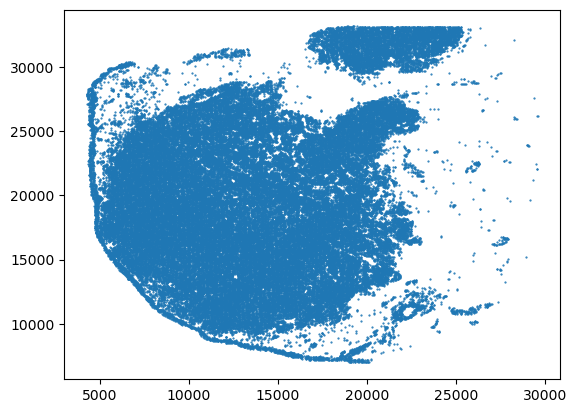

In [4]:
plt.scatter(adata.obsm["spatial"][:,0], adata.obsm["spatial"][:,1], s=0.3)

In [5]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata)

2025-03-20 15:55:51.629155: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-20 15:55:51.649286: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-20 15:55:51.672213: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-20 15:55:51.678965: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-20 15:55:51.695912: I tensorflow/core/platform/cpu_feature_guar

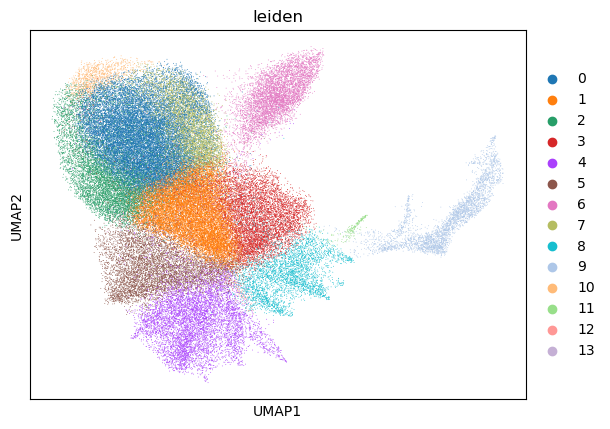

In [6]:
# PCA
sc.tl.pca(adata)
# Compute nearest neighbors
sc.pp.neighbors(adata)
# UMAP for visualization
sc.tl.umap(adata)
# Clustering
sc.tl.leiden(adata, resolution=0.8)  
# Visualize clusters
sc.pl.umap(adata, color=["leiden"])

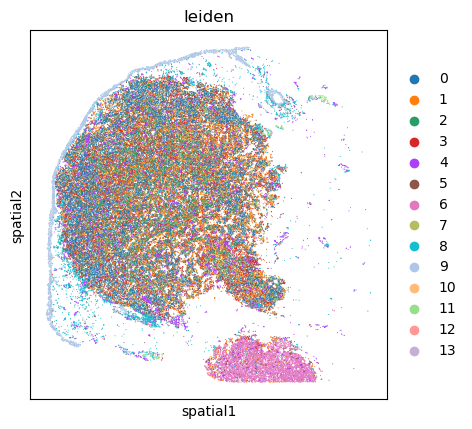

In [7]:
sc.pl.spatial(adata, color='leiden', spot_size=80, alpha_img=1)

In [8]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")

In [9]:
adata.obs["leiden"].value_counts()

0     18017
1     13482
2      7938
3      7582
4      7100
5      6915
6      5420
7      5350
8      3730
9      3359
10     1069
11      234
12      155
13       14
Name: leiden, dtype: int64

In [10]:
#for cell_type in adata.obs["leiden"].unique():
#    sc.pl.spatial(adata[adata.obs["leiden"] == cell_type], color='leiden', spot_size=50, alpha_img=1)

In [11]:
clusters = adata.obs['leiden'].unique()
de_results = {}
for cluster in clusters:
    cluster_results = pd.DataFrame({
        'gene': adata.uns['rank_genes_groups']['names'][cluster],
        'logfoldchanges': adata.uns['rank_genes_groups']['logfoldchanges'][cluster],
        'pvals': adata.uns['rank_genes_groups']['pvals'][cluster],
        'pvals_adj': adata.uns['rank_genes_groups']['pvals_adj'][cluster]
    })
    #only include positive logfoldchanges
    #cluster_results = cluster_results[cluster_results['logfoldchanges'] > 0]
    de_results[cluster] = cluster_results

#print the top 20 genes for each cluster sorted by p-value
for cluster, results in de_results.items():
    print(f"Cluster {cluster}")
    print(results.head(50))
    print("\n")

Cluster 2
        gene  logfoldchanges          pvals      pvals_adj
0     S100A6             NaN   0.000000e+00   0.000000e+00
1   SERPINE2             NaN   0.000000e+00   0.000000e+00
2     LGALS1             NaN  1.623743e-175  5.107484e-172
3     TMSB10             NaN  3.184083e-159  8.012425e-156
4       CD63             NaN  3.664140e-129  7.683701e-126
5      S100B             NaN  4.165128e-119  7.486521e-116
6        VGF             NaN  3.283707e-112  5.164449e-109
7      TIMP1             NaN   5.287547e-75   7.391991e-72
8        MIA             NaN   9.955085e-72   1.252549e-68
9       QPCT             NaN   2.111035e-71   2.414640e-68
10   S100A16             NaN   6.122073e-68   6.418994e-65
11     PLOD3             NaN   1.432613e-48   1.201676e-45
12   NDUFAF8             NaN   1.924822e-44   1.513632e-41
13      PMEL             NaN   3.088720e-44   2.286016e-41
14   SLC26A2             NaN   2.045576e-42   1.429857e-39
15     FXYD5             NaN   3.643904e-42   

In [12]:
cell_type_names = {
    "0": "Melanocytes",
    "1": "Melanocytes",
    "2": "Melanocytes",
    "3": "Macrophages",
    "4": "Endothelial Cells",
    "5": "CAFs",
    "6": "Melanocytes",
    "7": "Melanocytes",
    "8": "Macrophages",
    "9": "Keratinocytes",
    "10": "Melanocytes",
    "11": "Epithelial Cells",
    "12": "Smooth Muscle Cells",
    "13": "Uncertain/Low-confidence"
}

adata.obs["cell_type"] = adata.obs["leiden"].astype(str).map(cell_type_names)

In [13]:
#remove cells with low significance
adata = adata[~adata.obs["cell_type"].isin(["Uncertain/Low-confidence"])]

In [14]:
adata.obs["cell_annotation"] = np.where(adata.obs["cell_type"] == "Melanocytes", "Tumor", "TME")

... storing 'cell_type' as categorical
... storing 'cell_annotation' as categorical


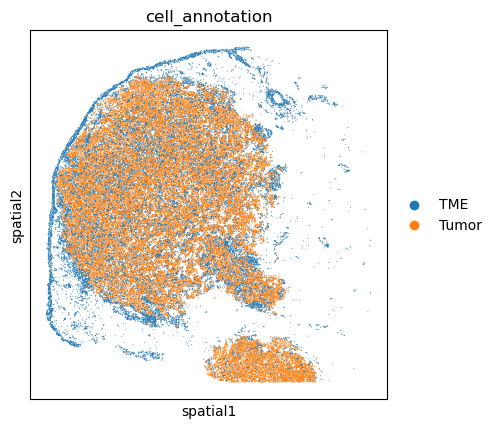

In [15]:
sc.pl.spatial(adata, color='cell_annotation', spot_size=70, alpha_img=1)

In [ ]:
#for cell_type in adata.obs["cell_type"].unique():
#    sc.pl.spatial(adata[adata.obs["cell_type"] == cell_type], color='cell_type', spot_size=100, alpha_img=1)

In [ ]:
#write the results to a file
#with open(data_directory + sample + "_de_results.txt", 'w') as f:
#    for cluster, results in de_results.items():
#        f.write(f"Cluster {cluster}\n")
#        f.write(results.head(50).to_string())
#        f.write("\n\n")

In [16]:
adata.write(data_directory + sample + "_" + um + "_processed.h5ad")